Everytime you want to check the high energy (HE) scale with Thorium data, you first need to create two files:

- A 3D map with $^{83\text{m}}\text{Kr}$ data previous to HE calibration campaign, which we assume constant in time.
- A H5 file with energy scale time evolution within the HE calibration campaign.

Both files are merged into a single one similar to low-background runs.

__NOTE:__ _this is valid until we get more details about Zemrude city._

In [25]:
import sys
sys.path.append('/lhome/ific/c/ccortesp/Analysis')

from libs import crudo

import glob
from invisible_cities.types.symbols import NormMethod
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

# Styling Plot
crudo.pt.ccortesp_plot_style()

%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Preliminary

In [ ]:
# Directories
ICAROS_LOW_BCKG_DIR = '/lustre/ific.uv.es/prj/gl/neutrinos/users/ccortesp/NEXT-100/Icaros/Low_background/2025/'
ICAROS_HE_DIR = '/lustre/ific.uv.es/prj/gl/neutrinos/users/ccortesp/NEXT-100/Icaros/HE_calibration/2025/'
OUTPUT_DIR = '/lhome/ific/c/ccortesp/Analysis/NEXT-100/Th_analysis/h5/'

# Runs list
RUNS_TO_COMBINE = [15546, 15547, 15557]      # Low-background runs to combine their maps
RUNS_FOR_ENERGY_SCALE = [15589]              # HE calibration runs to use for energy scale time evolution

# --- Helper Functions --- #
def merge_bins(df):
    """
    Merges data for a single bin (voxel) using a weighted average.
    """
    new_n  = df.nevents.sum()
    new_mu = np.sum(df.mu * df.nevents) / np.clip(new_n, 1, None)
    return pd.Series({'nevents': new_n, 'mu': new_mu})

def combine_maps(maps_list: list) -> pd.DataFrame:
    """
    Combines a list of Kr map DataFrames into a single, high-statistics map.
    """
    full_map = pd.concat(maps_list, ignore_index=True)
    # Columns that define a unique voxel
    voxel_id_columns = ['k', 'i', 'j', 'dt', 'x', 'y'] 
    combined_map = full_map.groupby(voxel_id_columns).apply(merge_bins).reset_index()
    return combined_map

def create_full_h5_scale(scale_list):
    """
    Combines a list of Kr time evolution DataFrames into a single DataFrame.
    It contains the time evolution of the energy scale (or yield) S2e.
    """
    full_scale = pd.concat(scale_list, ignore_index=True)
    # combined_scale = full_scale[['run_number', 'ts', 's2e', 's2eu']].rename(columns={'run_number': 'run', 'ts': 'time'})
    combined_scale = full_scale[['run_number', 'ts', 's2e', 's2eu']]
    return combined_scale

### Testing

In [8]:
# Icaros 2025
# test_file = '/lhome/ific/c/ccortesp/Analysis/NEXT-100/Th_analysis/h5/energy_scale_he.h5'
# test_file = '/lhome/ific/c/ccortesp/Analysis/NEXT-100/Th_analysis/h5/combined_15546_15557.map3d'

# Zemrude 2026
# test_file = '/lhome/ific/c/ccortesp/Analysis/NEXT-100/Th_analysis/h5/combined_15546_15557_zemrude_map.h5'
test_file = ICAROS_HE_DIR + 'run_15589.zemrude-test-7-ge5dc049e.20250717-26-g211f149.KrDesman.zemrude.h5'

crudo.dm.h5_describer(test_file)

data (Group)
  data/selection_efficiencies (Dataset)
    Shape: (1,), Dtype: [('eff_diffusion_band', '<f8'), ('eff_Xrays', '<f8'), ('eff_1S1_1S2', '<f8'), ('eff_S2_trigger_time', '<f8'), ('eff_Rmax', '<f8'), ('eff_range_DT', '<f8'), ('eff_NSiPMS', '<f8'), ('total_efficiency', '<f8')]
krmap (Group)
  krmap/krmap (Dataset)
    Shape: (100000,), Dtype: [('k', '<i8'), ('i', '<i8'), ('j', '<i8'), ('nevents', '<f8'), ('mu', '<f8'), ('sigma', '<f8'), ('mu_error', '<f8'), ('sigma_error', '<f8'), ('dt', '<f8'), ('x', '<f8'), ('y', '<f8'), ('density', '<f8')]
metadata (Group)
  metadata/axis0 (Dataset)
    Shape: (1,), Dtype: int64
  metadata/axis1 (Dataset)
    Shape: (15,), Dtype: |S11
  metadata/block0_items (Dataset)
    Shape: (1,), Dtype: int64
  metadata/block0_values (Dataset)
    Shape: (1,), Dtype: object
t_evol (Group)
  t_evol/t_evol (Dataset)
    Shape: (13,), Dtype: [('run_number', '<i4'), ('ts', '<i8'), ('nevents', '<i8'), ('neventsu', '<f8'), ('rate', '<f8'), ('rateu', '<f8'), ('

In [6]:
test_df = pd.read_hdf(test_file, key='t_evol/t_evol')
test_df

,run_number,ts,nevents,neventsu,rate,rateu,s2e,s2eu,ec1,ec1u,...,s2q,s2qu,Nsipm,Nsipmu,Xrms,Xrmsu,Yrms,Yrmsu,Zrms,Zrmsu
0,15589,1751990253,25120,158.492902,3.488889,0.022013,7599.822696,5.031297,42.148720,0.020771,...,573.042595,0.930253,16.796338,0.012704,14.143390,0.008986,14.145005,0.008967,4.164974,0.008159
1,15589,1751997454,24772,157.391232,3.441033,0.021863,7610.344090,5.937974,42.150047,0.020442,...,572.385719,0.993134,16.813176,0.012868,14.154075,0.009098,14.159430,0.009173,4.177111,0.008257
2,15589,1752004653,24087,155.199871,3.345417,0.021556,7604.480474,5.402551,42.163426,0.021650,...,572.117517,0.959886,16.817246,0.013173,14.160410,0.009261,14.152845,0.009271,4.175788,0.008361
3,15589,1752011853,23951,154.761106,3.326528,0.021495,7597.232975,5.894477,42.151183,0.021314,...,571.426603,0.983983,16.786689,0.013131,14.139097,0.009272,14.153688,0.009295,4.170686,0.008432
4,15589,1752019054,23425,153.052279,3.253924,0.021260,7600.864132,5.721678,42.154027,0.020308,...,572.406354,1.003724,16.803458,0.013210,14.146415,0.009317,14.143600,0.009430,4.167020,0.008487
5,15589,1752026253,23144,152.131522,3.214444,0.021129,7600.545385,5.926514,42.144779,0.021532,...,571.214137,1.006476,16.809713,0.013303,14.156255,0.009370,14.162500,0.009433,4.178227,0.008559
6,15589,1752033453,22964,151.538774,3.189444,0.021047,7610.288040,6.582587,42.177115,0.021642,...,571.730321,1.028116,16.804259,0.013481,14.146703,0.009491,14.155074,0.009488,4.173951,0.008567
7,15589,1752040653,22040,148.458748,3.061536,0.020622,7601.429390,5.653614,42.185485,0.020869,...,571.363385,1.008591,16.808348,0.013753,14.164856,0.009616,14.164450,0.009694,4.185884,0.008699
8,15589,1752047853,21490,146.594679,2.985137,0.020363,7600.514196,5.763895,42.185161,0.021625,...,569.848457,1.021591,16.786133,0.013930,14.147634,0.009733,14.153901,0.009719,4.183849,0.008849
9,15589,1752055053,20858,144.422990,2.896944,0.020059,7602.095590,6.016344,42.182072,0.020539,...,568.635684,1.049327,16.792837,0.014040,14.166721,0.009894,14.162615,0.009911,4.196091,0.008965


# Combine 3D Map

In [10]:
# List of maps to combine
list_maps_h5 = []

for file in os.listdir(ICAROS_LOW_BCKG_DIR):

    if any(str(run) in file for run in RUNS_TO_COMBINE) and 'zemrude' in file:

        filename = os.path.join(ICAROS_LOW_BCKG_DIR, file)
        print(f"{os.path.basename(filename)} map will be combined.")
        # print(filename)

        df = pd.read_hdf(filename, key='krmap/krmap')
        list_maps_h5.append(df)

run_15557.zemrude-test-7-ge5dc049e.20250717-26-g211f149.KrDesman.zemrude.h5 map will be combined.
run_15547.zemrude-test-7-ge5dc049e.20250717-26-g211f149.KrDesman.zemrude.h5 map will be combined.
run_15546.zemrude-test-7-ge5dc049e.20250717-26-g211f149.KrDesman.zemrude.h5 map will be combined.


In [ ]:
# Combine the maps using the weighted average functions
COMBINED_MAP_DF = combine_maps(list_maps_h5)
COMBINED_MAP_DF
print("Combination complete.")

Combination complete.


How does it look?

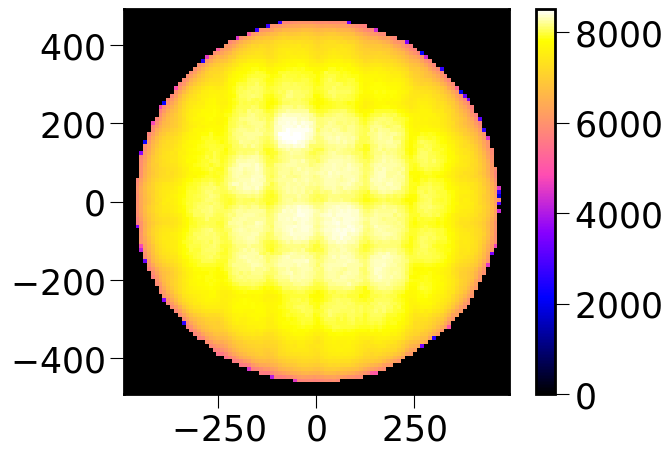

In [17]:
# Check the map in the anode region (k=0)
zem_map = COMBINED_MAP_DF[COMBINED_MAP_DF['k'] == 0].copy()
plt.figure(figsize=(7, 5))
plt.imshow(zem_map['mu'].values.reshape(100, 100).T, origin='lower', extent=(-crudo.pt.N100_rad, crudo.pt.N100_rad,-crudo.pt.N100_rad, crudo.pt.N100_rad))
plt.colorbar()

# Energy Scale Evolution

In [18]:
# List of h5 files to use for energy scale time evolution
list_scale_h5 = []

for file in os.listdir(ICAROS_HE_DIR):

    if any(str(run) in file for run in RUNS_FOR_ENERGY_SCALE) and 'zemrude' in file:

        filename = os.path.join(ICAROS_HE_DIR, file)
        print(f"{os.path.basename(filename)} file will be used.")

        df = pd.read_hdf(filename, key='t_evol/t_evol')
        list_scale_h5.append(df)

run_15589.zemrude-test-7-ge5dc049e.20250717-26-g211f149.KrDesman.zemrude.h5 file will be used.


In [ ]:
# Combine the energy scale dataframes
COMBINED_SCALE_DF = create_full_h5_scale(list_scale_h5)
COMBINED_SCALE_DF
print("Combination complete.")


Combination complete.


# Output

Finally, we want to have both information (spatial and time) in one $\sim\text{Kr}$ file.

In [27]:
output_filename = f'runs_{RUNS_FOR_ENERGY_SCALE[0]}_{RUNS_FOR_ENERGY_SCALE[-1]}_zemrude.h5'
output_filepath = os.path.join(OUTPUT_DIR, output_filename)

print(f"Opening HDF5 store for writing: {output_filepath}")
try:
    with pd.HDFStore(output_filepath, mode='w') as store:
        if not COMBINED_MAP_DF.empty:
            store.put('krmap/krmap', COMBINED_MAP_DF, format='table', data_columns=True)
        if not COMBINED_SCALE_DF.empty:
            store.put('t_evol/t_evol', COMBINED_SCALE_DF, format='table', data_columns=True)
    print("HDF5 saving complete.")
except Exception as e:
    print(f"   Error writing to HDF5 file: {e}", file=sys.stderr)

# You have reasonable values?
corr3d = crudo.ef.get_corr3d(output_filepath, norm_method=NormMethod.median_anode)     # If this fails look at the used key in the function
print(f'\nCorrection value @ center of anode: {corr3d([0], [0], [0])}')

Opening HDF5 store for writing: /lhome/ific/c/ccortesp/Analysis/NEXT-100/Th_analysis/h5/runs_15589_15589_zemrude.h5
HDF5 saving complete.

Correction value @ center of anode: [0.96403413]
